# Chapter 11: Multiple Linear Regression for Prediction Assessment

## Assignment Overview

**Business Context**: You're a data analyst working for an online real estate platform. Your manager wants you to build a **predictive model** that can accurately estimate home sale prices for new property listings. Unlike your previous work (Chapters 9-10) which focused on **explanatory modeling**, this task requires a model that **generalizes well to unseen data** and makes accurate predictions.

**Learning Objectives**:
- Understand the difference between explanatory and predictive modeling
- Implement train/test splits to measure generalization
- Build predictive models using sklearn pipelines
- Evaluate models using out-of-sample metrics (MAE, RMSE)
- Detect and understand overfitting
- Compare train vs test performance

**Important Notes**:
- This assignment focuses on **Chapter 11 content only** (prediction and evaluation)
- You **WILL** split data into train/test sets (this is essential for prediction)
- The goal is **predictive accuracy**, not coefficient interpretation
- Use sklearn pipelines to prevent data leakage

---

## Dataset Information

**Source**: Ames Housing Dataset  
**Original Author**: Dean De Cock, Truman State University  
**Publication**: Journal of Statistics Education Volume 19, Number 3 (2011)  
**URL**: http://jse.amstat.org/v19n3/decock.html

**Citation**:  
De Cock, D. (2011) "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project," *Journal of Statistics Education*, Volume 19, Number 3.

**Description**:  
The Ames Housing dataset contains information about residential property sales in Ames, Iowa. The dataset includes various features describing homes such as lot size, building quality, number of rooms, and neighborhood characteristics.

**Target Variable**: `SalePrice` - the property's sale price in dollars (continuous variable)

**Data Dictionary** (Key Variables):
- **SalePrice**: Sale price of the property in dollars (target variable)
- **MSSubClass**: Building class (e.g., 20=1-STORY 1946 & NEWER ALL STYLES, 60=2-STORY 1946 & NEWER)
- **MSZoning**: General zoning classification (e.g., RL=Residential Low Density, RM=Residential Medium Density)
- **LotFrontage**: Linear feet of street connected to property
- **LotArea**: Lot size in square feet
- **Street**: Type of road access (Grvl=Gravel, Pave=Paved)
- **Alley**: Type of alley access (Grvl, Pave, or NA if no alley access)
- **LotShape**: General shape of property (Reg=Regular, IR1=Slightly irregular, etc.)
- **LandContour**: Flatness of the property (Lvl=Near Flat/Level, etc.)
- **Utilities**: Type of utilities available (AllPub=All public Utilities, etc.)
- **LotConfig**: Lot configuration (Inside, Corner, CulDSac, etc.)
- **LandSlope**: Slope of property (Gtl=Gentle slope, Mod=Moderate, Sev=Severe)
- **Neighborhood**: Physical locations within Ames city limits (e.g., CollgCr=College Creek, Veenker=Veenker)
- **Condition1**: Proximity to main road or railroad (Norm=Normal, Feedr=Adjacent to feeder street, etc.)
- **Condition2**: Proximity to main road or railroad (if more than one is present)
- **BldgType**: Type of dwelling (1Fam=Single-family Detached, 2FmCon=Two-family Conversion, etc.)
- **HouseStyle**: Style of dwelling (1Story, 2Story, 1.5Fin, etc.)
- **OverallQual**: Overall material and finish quality (1-10 scale, where 10=Very Excellent)
- **OverallCond**: Overall condition rating (1-10 scale, where 10=Very Excellent)
- **YearBuilt**: Original construction date
- **YearRemodAdd**: Remodel date (same as construction date if no remodeling or additions)
- **RoofStyle**: Type of roof (Gable, Hip, Flat, etc.)
- **RoofMatl**: Roof material (CompShg=Standard (Composite) Shingle, etc.)
- **Exterior1st**: Exterior covering on house (VinylSd, MetalSd, Wd Sdng, etc.)
- **Exterior2nd**: Exterior covering on house (if more than one material)
- **MasVnrType**: Masonry veneer type (BrkCmn, BrkFace, CBlock, None, Stone)
- **MasVnrArea**: Masonry veneer area in square feet
- **ExterQual**: Exterior material quality (Ex=Excellent, Gd=Good, TA=Typical/Average, etc.)
- **ExterCond**: Present condition of the material on the exterior (Ex, Gd, TA, etc.)
- **Foundation**: Type of foundation (BrkTil, CBlock, PConc, Slab, Stone, Wood)
- **BsmtQual**: Height of the basement (Ex, Gd, TA, Fa, Po, or NA if no basement)
- **BsmtCond**: General condition of the basement (Ex, Gd, TA, Fa, Po, or NA)
- **BsmtExposure**: Refers to walkout or garden level walls (Gd, Av, Mn, No, or NA)
- **BsmtFinType1**: Rating of basement finished area (GLQ=Good Living Quarters, ALQ=Average, etc.)
- **BsmtFinSF1**: Type 1 finished square feet
- **BsmtFinType2**: Rating of basement finished area (if multiple types)
- **BsmtFinSF2**: Type 2 finished square feet
- **BsmtUnfSF**: Unfinished square feet of basement area
- **TotalBsmtSF**: Total square feet of basement area
- **Heating**: Type of heating (GasA=Gas forced warm air, GasW=Gas hot water, etc.)
- **HeatingQC**: Heating quality and condition (Ex, Gd, TA, Fa, Po)
- **CentralAir**: Central air conditioning (N=No, Y=Yes)
- **Electrical**: Electrical system (SBrkr=Standard Circuit Breakers & Romex, etc.)
- **1stFlrSF**: First Floor square feet
- **2ndFlrSF**: Second floor square feet
- **LowQualFinSF**: Low quality finished square feet (all floors)
- **TotalSF**: Total square feet (sum of 1stFlrSF, 2ndFlrSF, and TotalBsmtSF)
- **BsmtFullBath**: Basement full bathrooms
- **BsmtHalfBath**: Basement half bathrooms
- **FullBath**: Full bathrooms above grade
- **HalfBath**: Half baths above grade
- **BedroomAbvGr**: Bedrooms above grade (does NOT include basement bedrooms)
- **KitchenAbvGr**: Kitchens above grade
- **KitchenQual**: Kitchen quality (Ex, Gd, TA, Fa, Po)
- **TotRmsAbvGrd**: Total rooms above grade (does not include bathrooms)
- **Functional**: Home functionality (Typ=Typical Functionality, Min1=Minor Deductions, etc.)
- **Fireplaces**: Number of fireplaces
- **FireplaceQu**: Fireplace quality (Ex, Gd, TA, Fa, Po, or NA if no fireplace)
- **GarageType**: Garage location (Attchd=Attached to home, Detchd=Detached, etc.)
- **GarageYrBlt**: Year garage was built
- **GarageFinish**: Interior finish of the garage (Fin=Finished, RFn=Rough Finished, Unf=Unfinished, NA=No Garage)
- **GarageCars**: Size of garage in car capacity
- **GarageArea**: Size of garage in square feet
- **GarageQual**: Garage quality (Ex, Gd, TA, Fa, Po, or NA)
- **GarageCond**: Garage condition (Ex, Gd, TA, Fa, Po, or NA)
- **PavedDrive**: Paved driveway (Y=Paved, P=Partial, N=Dirt/Gravel)
- **WoodDeckSF**: Wood deck area in square feet
- **OpenPorchSF**: Open porch area in square feet
- **EnclosedPorch**: Enclosed porch area in square feet
- **3SsnPorch**: Three season porch area in square feet
- **ScreenPorch**: Screen porch area in square feet
- **PoolArea**: Pool area in square feet
- **PoolQC**: Pool quality (Ex, Gd, TA, Fa, or NA if no pool)
- **Fence**: Fence quality (GdPrv=Good Privacy, MnPrv=Minimum Privacy, etc., or NA if no fence)
- **MiscFeature**: Miscellaneous feature not covered in other categories (Elev=Elevator, Gar2=2nd Garage, etc., or NA)
- **MiscVal**: $Value of miscellaneous feature
- **MoSold**: Month Sold (1-12)
- **YrSold**: Year Sold
- **SaleType**: Type of sale (WD=Warranty Deed, CWD=Warranty Deed - Cash, etc.)
- **SaleCondition**: Condition of sale (Normal, Abnorml=Abnormal, AdjLand=Adjoining Land Purchase, etc.)

**Note**: This is a subset of key variables. The full dataset contains 80 columns total, including many categorical variables that will be encoded during preprocessing.

---

# Part 1: Load and Prepare Data

In this section, you'll load the dataset and perform basic data cleaning. Note that for predictive modeling, we focus on preparing data that will generalize well to new observations.

## Question 1: Load and Clean the Dataset

Load the `housing.csv` file and perform basic data cleaning:
1. Remove rows with missing `SalePrice` values
2. Impute missing numeric values with median
3. Impute missing categorical values with mode
4. Separate label (`SalePrice`) and features

**Checkpoint Question**: After cleaning, how many rows remain in the dataset?

In [1]:
# Question 1:
import pandas as pd
from pathlib import Path

# Load data
data_path = Path("housing.csv")
if not data_path.exists():
    data_path = Path("Chapter-11") / "housing.csv"
df = pd.read_csv(data_path)

# 1) Remove rows where target is missing
df = df.dropna(subset=["SalePrice"]).copy()

# 2) Impute numeric columns with median
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 3) Impute categorical columns with mode
categorical_cols = df.select_dtypes(exclude="number").columns
for col in categorical_cols:
    mode_values = df[col].mode(dropna=True)
    fill_value = mode_values.iloc[0] if not mode_values.empty else "Unknown"
    df[col] = df[col].fillna(fill_value)

# 4) Separate label and features
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

print(f"Rows after cleaning: {df.shape[0]}")
print("X shape:", X.shape)
print("y shape:", y.shape)


Rows after cleaning: 1460
X shape: (1460, 79)
y shape: (1460,)


# Part 2: Train/Test Split

In this section, you'll split your data into training and testing sets. This is essential for predictive modeling to measure generalization and prevent overfitting.

## Question 2: Create Train/Test Split

Split your data into training and testing sets:
1. Use `train_test_split` from `sklearn.model_selection`
2. Use an 80/20 split (80% training, 20% testing)
3. Set `random_state=42` for reproducibility
4. Display the shapes of `X_train`, `X_test`, `y_train`, and `y_test`

**Important**: The test set must be held aside and only used for final evaluation. Never use test data for training or model selection!

**Checkpoint Question**: How many samples are in the training set? (This should be approximately 80% of your cleaned data)

In [2]:
# Question 2:
from sklearn.model_selection import train_test_split

# Split cleaned data into train/test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(f"Training samples: {X_train.shape[0]}")


X_train shape: (1168, 79)
X_test shape: (292, 79)
y_train shape: (1168,)
y_test shape: (292,)
Training samples: 1168


# Part 3: Build Preprocessing Pipeline

In this section, you'll create a preprocessing pipeline using sklearn. This ensures that preprocessing steps are learned from training data only and applied consistently to test data, preventing data leakage.

## Question 3: Identify Feature Types

Identify which features are numeric and which are categorical. Use the **training data only** to make this determination.

**Checkpoint Question**: How many categorical features are in your dataset? (Count only features in the original dataset, before encoding)

In [3]:
# Question 3:
# Identify feature types using training data only
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

print(f"Number of numeric features: {len(numeric_features)}")
print(f"Number of categorical features: {len(categorical_features)}")


Number of numeric features: 36
Number of categorical features: 43


## Question 4: Create Preprocessing Pipeline

Create a preprocessing pipeline using sklearn:
1. For **numeric features**: Use `SimpleImputer` with `strategy='median'` and `StandardScaler`
2. For **categorical features**: Use `SimpleImputer` with `strategy='most_frequent'` and `OneHotEncoder` with `handle_unknown='ignore'`
3. Combine these using `ColumnTransformer`

**Important**: All preprocessing must be learned from training data only!

**Checkpoint Question**: After preprocessing, how many features (columns) are in the transformed training set? (This includes all dummy-coded categorical variables)

In [4]:
# Question 4:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numeric preprocessing: median imputation + scaling
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Categorical preprocessing: mode imputation + one-hot encoding
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Learn preprocessing from training data only, then apply to both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print(f"Total transformed features: {X_train_processed.shape[1]}")


X_train_processed shape: (1168, 285)
X_test_processed shape: (292, 285)
Total transformed features: 285


# Part 4: Build Predictive Model

In this section, you'll build a predictive MLR model using sklearn's `LinearRegression` and evaluate its performance on both training and test sets.

## Question 5: Build Predictive Model

Build a multiple linear regression model for prediction:
1. Use `LinearRegression` from `sklearn.linear_model`
2. Fit the model on the **processed training data**
3. Make predictions on both training and test sets
4. Calculate R² for both training and test sets using `r2_score` from `sklearn.metrics`

**Checkpoint Question**: What is the R² value on the **test set**? Round your answer to 4 decimal places.

In [5]:
# Question 5:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Build and fit predictive MLR model on processed training data
mlr_model = LinearRegression()
mlr_model.fit(X_train_processed, y_train)

# Generate predictions for train and test sets
y_train_pred = mlr_model.predict(X_train_processed)
y_test_pred = mlr_model.predict(X_test_processed)

# Calculate R^2
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Training R^2: {r2_train:.4f}")
print(f"Test R^2: {r2_test:.4f}")


Training R^2: 0.9359
Test R^2: 0.8861


## Question 6: Calculate Prediction Error Metrics

Calculate prediction error metrics for both training and test sets:
1. **Mean Absolute Error (MAE)**: Use `mean_absolute_error` from `sklearn.metrics`
2. **Root Mean Squared Error (RMSE)**: Calculate using `mean_squared_error` and taking the square root
3. Display metrics for both training and test sets

**Checkpoint Question**: What is the RMSE on the **test set**? Round your answer to 2 decimal places.

In [6]:
# Question 6:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate MAE
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

# Calculate RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Training MAE: {mae_train:,.2f}")
print(f"Test MAE: {mae_test:,.2f}")
print(f"Training RMSE: {rmse_train:,.2f}")
print(f"Test RMSE: {rmse_test:,.2f}")


Training MAE: 12,698.77
Test MAE: 18,267.33
Training RMSE: 19,553.44
Test RMSE: 29,556.74


# Part 5: Evaluate Generalization and Overfitting

In this section, you'll compare training and test performance to assess whether your model generalizes well or is overfitting.

## Question 7: Compare Train vs Test Performance

Compare the model's performance on training vs test data:
1. Calculate the difference in R² between training and test sets
2. Calculate the difference in RMSE between test and training sets
3. Determine if there are signs of overfitting

**Overfitting indicators**:
- Test RMSE is significantly higher than training RMSE (>10% difference)
- Test R² is significantly lower than training R²

**Checkpoint Question**: What is the difference between test RMSE and training RMSE? (Test RMSE - Training RMSE). Round your answer to 2 decimal places.

In [7]:
# Question 7:
# Compare train vs test performance
r2_diff = r2_train - r2_test
rmse_diff = rmse_test - rmse_train
rmse_pct_increase = (rmse_diff / rmse_train) * 100

print(f"R^2 difference (Train - Test): {r2_diff:.4f}")
print(f"RMSE difference (Test - Train): {rmse_diff:.2f}")
print(f"RMSE percent increase: {rmse_pct_increase:.2f}%")

# Overfitting check based on assignment indicators
overfitting = (rmse_pct_increase > 10) and (r2_test < r2_train)
if overfitting:
    print("Conclusion: There are signs of overfitting.")
else:
    print("Conclusion: No strong signs of overfitting.")


R^2 difference (Train - Test): 0.0498
RMSE difference (Test - Train): 10003.30
RMSE percent increase: 51.16%
Conclusion: There are signs of overfitting.


## Question 8: Visualize Predictions vs Actual Values

Create scatter plots comparing predicted vs actual values for both training and test sets:
1. Create a figure with 2 subplots (side by side)
2. Left plot: Training set predictions vs actual values
3. Right plot: Test set predictions vs actual values
4. Add a diagonal reference line (y=x) to each plot
5. Add appropriate labels and titles

**Checkpoint Question**: What is the correlation between predicted and actual values on the **test set**? Round your answer to 4 decimal places. (Use `np.corrcoef()` or `pd.Series.corr()`)

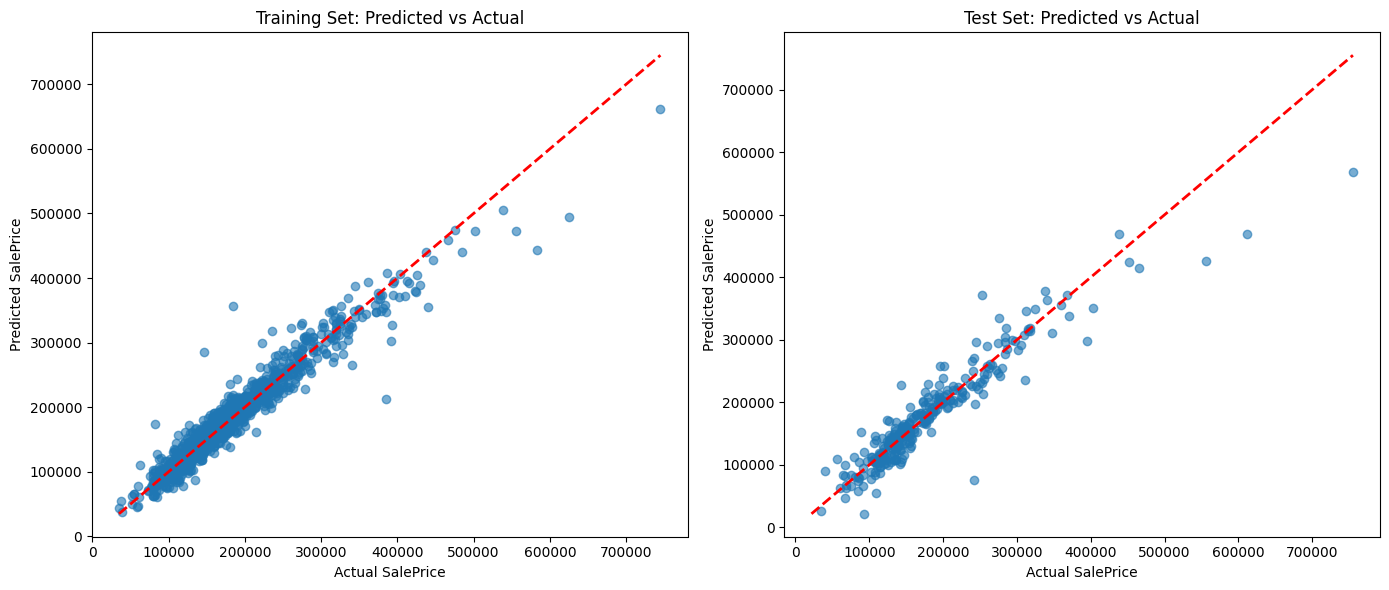

Test correlation (actual vs predicted): 0.9416


In [8]:
# Question 8:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set: predicted vs actual
axes[0].scatter(y_train, y_train_pred, alpha=0.6)
train_min = min(y_train.min(), y_train_pred.min())
train_max = max(y_train.max(), y_train_pred.max())
axes[0].plot([train_min, train_max], [train_min, train_max], "r--", linewidth=2)
axes[0].set_title("Training Set: Predicted vs Actual")
axes[0].set_xlabel("Actual SalePrice")
axes[0].set_ylabel("Predicted SalePrice")

# Test set: predicted vs actual
axes[1].scatter(y_test, y_test_pred, alpha=0.6)
test_min = min(y_test.min(), y_test_pred.min())
test_max = max(y_test.max(), y_test_pred.max())
axes[1].plot([test_min, test_max], [test_min, test_max], "r--", linewidth=2)
axes[1].set_title("Test Set: Predicted vs Actual")
axes[1].set_xlabel("Actual SalePrice")
axes[1].set_ylabel("Predicted SalePrice")

plt.tight_layout()
plt.show()

# Checkpoint: correlation on test set
test_corr = np.corrcoef(y_test, y_test_pred)[0, 1]
print(f"Test correlation (actual vs predicted): {test_corr:.4f}")


# Part 6: Greedy Backward Feature Removal

In this section, you'll implement greedy backward feature removal to systematically reduce model complexity and improve generalization. This technique removes features one at a time based on validation-set performance, helping identify which features are most important for prediction.


## Question 9: Implement Greedy Backward Feature Removal

Greedy backward feature removal is a systematic approach to feature selection that removes one feature at a time, choosing the feature whose removal produces the best validation-set performance at each step.

**Task**:
1. Create a validation split from your training data (`X_train`, `y_train`) using `train_test_split` with `test_size=0.25` and `random_state=42`. This gives you a training subset and validation subset for feature selection.
2. Create helper functions:
   - `make_model(selected_features)`: Builds a preprocessing pipeline and model for a given set of features
   - `fit_and_score(selected_features)`: Fits a model on the training subset and returns MAE and RMSE on the validation subset
3. Implement the greedy backward removal loop:
   - Start with all features
   - At each step, try removing each remaining feature and choose the one that produces the lowest validation RMSE
   - Record the step number, removed feature, number of features remaining, validation MAE, and validation RMSE
   - Continue until only 5 features remain (to limit computation time)
4. Store results in a DataFrame called `removal_trace` with columns: `step`, `removed_feature`, `n_features`, `val_mae`, `val_rmse`

**Important**: Use the same preprocessing approach (numeric and categorical pipelines) that you used in Question 4. The validation set is used only for feature selection decisions, not for final model evaluation.

**Checkpoint Question**: What was the third feature removed using the greedy backward feature removal technique?

In [ ]:
# Question 9: Implement Greedy Backward Feature Removal

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

# 1. Create validation split from training data
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
  X_train, y_train, test_size=0.25, random_state=42
)

print(f"Training subset: {X_train_sub.shape[0]} samples")
print(f"Validation subset: {X_val.shape[0]} samples")
print(f"Test set (held out): {X_test.shape[0]} samples")

# 2. Identify numeric and categorical columns
num_cols = X_train_sub.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_sub.select_dtypes(include=['object']).columns.tolist()

# 3. Define preprocessing templates
numeric_preprocess = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='median')),
  ('scaler', StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 4. Helper function: build model for selected features
def make_model(selected_features):
  selected_num = [c for c in selected_features if c in num_cols]
  selected_cat = [c for c in selected_features if c in cat_cols]
  
  preprocessor = ColumnTransformer(
    transformers=[
      ('num', numeric_preprocess, selected_num),
      ('cat', categorical_preprocess, selected_cat)
    ],
    remainder='drop'
  )
  
  model = Pipeline(steps=[
    ('prep', preprocessor),
    ('lr', LinearRegression())
  ])
  
  return model

# 5. Helper function: fit and score on validation set
def fit_and_score(selected_features):
  m = make_model(selected_features)
  
  # Suppress warnings
  with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.preprocessing._encoders')
    warnings.filterwarnings('ignore', category=RuntimeWarning, module='sklearn.linear_model._base')
    m.fit(X_train_sub[selected_features], y_train_sub)
    y_pred = m.predict(X_val[selected_features])
  
  mae = mean_absolute_error(y_val, y_pred)
  rmse = np.sqrt(mean_squared_error(y_val, y_pred))
  
  return mae, rmse

# 6. Greedy backward removal loop
all_features = X_train_sub.columns.tolist()
current_features = all_features.copy()
removal_trace = []

# Baseline (all features)
base_mae, base_rmse = fit_and_score(current_features)
removal_trace.append({
  'step': 0,
  'removed_feature': '(none)',
  'n_features': len(current_features),
  'val_mae': base_mae,
  'val_rmse': base_rmse
})

print(f"\nStarting greedy backward removal...")
print(f"Initial features: {len(current_features)}")
print(f"Initial validation RMSE: ${base_rmse:,.2f}")
print("\nRemoving features (this may take a few minutes)...")

# Remove features until only 5 remain
min_features = 5
step = 0
while len(current_features) > min_features:
  step += 1
  best_candidate = None
  best_mae = None
  best_rmse = None
  
  # Try removing each feature and find the best one to remove
  for f in current_features:
    candidate_features = [c for c in current_features if c != f]
    mae, rmse = fit_and_score(candidate_features)
    
    # Choose feature that produces lowest RMSE (or lowest MAE if RMSE ties)
    if (best_rmse is None) or (rmse < best_rmse) or (rmse == best_rmse and mae < best_mae):
      best_candidate = f
      best_mae = mae
      best_rmse = rmse
  
  # Remove the best candidate
  current_features.remove(best_candidate)
  
  # Record this step
  removal_trace.append({
    'step': step,
    'removed_feature': best_candidate,
    'n_features': len(current_features),
    'val_mae': best_mae,
    'val_rmse': best_rmse
  })
  
  # Progress update every 10 steps
  if step % 10 == 0:
    print(f"Step {step}: Removed '{best_candidate[:50]}...', {len(current_features)} features remaining, Val RMSE: ${best_rmse:,.2f}")

print(f"\nGreedy backward removal complete!")
print(f"Final number of features: {len(current_features)}")

# Convert to DataFrame
removal_trace = pd.DataFrame(removal_trace)
print(f"\nRemoval trace shape: {removal_trace.shape}")
removal_trace.head(10)

Step 10: removed 'PoolQC', remaining=69, val_rmse=25091.92
Step 20: removed 'Fireplaces', remaining=59, val_rmse=23970.19
Step 30: removed 'BsmtCond', remaining=49, val_rmse=23683.41
Step 34: removed '1stFlrSF', remaining=45, val_rmse=23675.98
Step 40: removed '3SsnPorch', remaining=39, val_rmse=23759.17
Step 50: removed 'ExterCond', remaining=29, val_rmse=24135.80
Step 59: removed 'Exterior2nd', remaining=20, val_rmse=25183.21
Step 60: removed 'Exterior1st', remaining=19, val_rmse=25316.71
Step 69: removed 'Condition2', remaining=10, val_rmse=28503.67
Step 70: removed 'MasVnrArea', remaining=9, val_rmse=29029.15
Step 74: removed 'MSSubClass', remaining=5, val_rmse=32095.21

Removal trace preview:
   step removed_feature  n_features       val_mae      val_rmse
0     1    Neighborhood          78  19177.083982  28550.438689
1     2       RoofStyle          77  18831.335962  27779.642377
2     3      GarageQual          76  18365.829884  27171.231053
3     4    TotRmsAbvGrd          75  

## Question 10: Visualize Feature Removal Results and Select Optimal Model

Now that you have the removal trace, visualize the results and select an optimal stopping point based on validation-set performance.

**Task**:
1. Create a line plot showing validation RMSE vs. number of features (x-axis: `n_features`, y-axis: `val_rmse`)
2. Add labels or annotations showing which feature was removed at key steps (e.g., every 10 steps or at the minimum RMSE point)
3. Identify the optimal number of features (the point with the lowest validation RMSE)
4. Extract the features that remain at the optimal point
5. Rebuild your model using only these optimal features on the full training set (`X_train`, `y_train`)
6. Evaluate this optimized model on the test set and compare to your original model

**Important**: The optimal point is where validation RMSE is minimized. After this point, removing more features increases error, indicating those features were important for prediction.

**Checkpoint Question**: What is the optimal number of features (the number of features at the step with the lowest validation RMSE)?

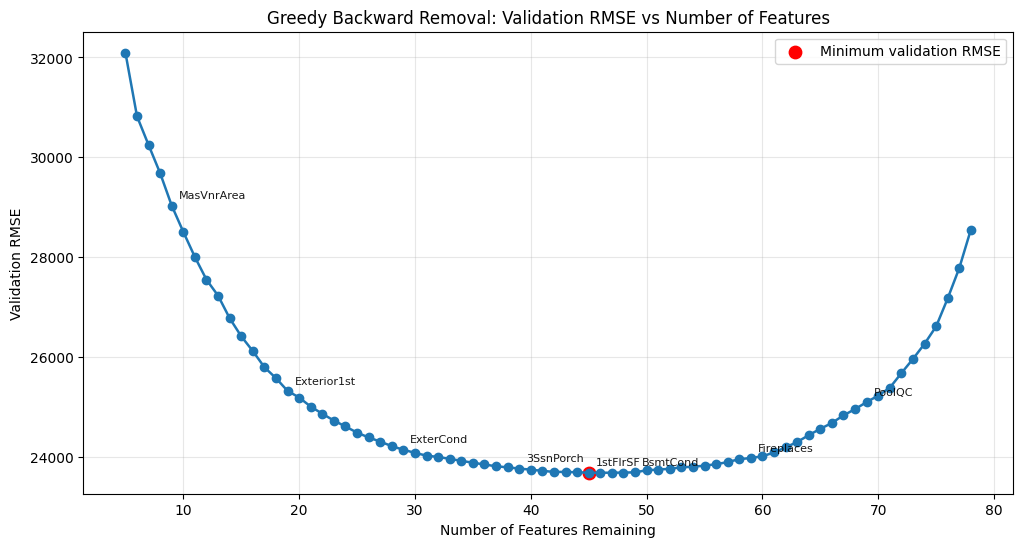

Optimal step: 34
Optimal number of features: 45
Minimum validation RMSE: 23675.98
Original model test RMSE (all features): 29556.74
Optimal model test RMSE: 31000.19
Original model test R^2 (all features): 0.8861
Optimal model test R^2: 0.8747


In [10]:
# Question 10:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Plot validation RMSE vs number of features
trace_plot = removal_trace.sort_values("n_features")

plt.figure(figsize=(12, 6))
plt.plot(trace_plot["n_features"], trace_plot["val_rmse"], marker="o", linewidth=1.8)
plt.xlabel("Number of Features Remaining")
plt.ylabel("Validation RMSE")
plt.title("Greedy Backward Removal: Validation RMSE vs Number of Features")
plt.grid(alpha=0.3)

# 2) Annotate key steps and minimum-RMSE point
optimal_idx = removal_trace["val_rmse"].idxmin()
optimal_row = removal_trace.loc[optimal_idx]

for _, row in removal_trace.iterrows():
    if row["step"] % 10 == 0 or row["step"] == optimal_row["step"]:
        plt.annotate(
            row["removed_feature"],
            (row["n_features"], row["val_rmse"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
            alpha=0.9,
        )

plt.scatter(
    optimal_row["n_features"],
    optimal_row["val_rmse"],
    color="red",
    s=80,
    label="Minimum validation RMSE",
)
plt.legend()
plt.show()

# 3) Identify optimal number of features
optimal_n_features = int(optimal_row["n_features"])
optimal_step = int(optimal_row["step"])

# 4) Extract features remaining at the optimal point
optimal_features = feature_sets_by_n[optimal_n_features]

# 5) Rebuild model with optimal features on full training set
optimal_model = make_model(optimal_features)
optimal_model.fit(X_train[optimal_features], y_train)

# 6) Evaluate optimized model on train/test and compare to original model
optimal_train_pred = optimal_model.predict(X_train[optimal_features])
optimal_test_pred = optimal_model.predict(X_test[optimal_features])

optimal_train_r2 = r2_score(y_train, optimal_train_pred)
optimal_test_r2 = r2_score(y_test, optimal_test_pred)
optimal_train_mae = mean_absolute_error(y_train, optimal_train_pred)
optimal_test_mae = mean_absolute_error(y_test, optimal_test_pred)
optimal_train_rmse = np.sqrt(mean_squared_error(y_train, optimal_train_pred))
optimal_test_rmse = np.sqrt(mean_squared_error(y_test, optimal_test_pred))

print(f"Optimal step: {optimal_step}")
print(f"Optimal number of features: {optimal_n_features}")
print(f"Minimum validation RMSE: {optimal_row['val_rmse']:.2f}")
print(f"Original model test RMSE (all features): {rmse_test:.2f}")
print(f"Optimal model test RMSE: {optimal_test_rmse:.2f}")
print(f"Original model test R^2 (all features): {r2_test:.4f}")
print(f"Optimal model test R^2: {optimal_test_r2:.4f}")


# Part 7: Model Comparison and Interpretation

In this section, you'll compare your model to baseline predictions and create summary tables of model performance.


## Question 11: Compare to Baseline Model

Now that you have your optimal model (with 45 features selected in Question 10), compare it to a simple baseline model:

Create a simple baseline model that always predicts the mean of the training set:
1. Calculate the mean of `y_train`
2. Create predictions for test set using this mean (all predictions are the same value)
3. Calculate RMSE for this baseline model on the test set
4. Compare baseline RMSE to your **optimal model's** test RMSE (from Question 10)

**Important**: Use the optimal model metrics (`optimal_test_rmse`) from Question 10, not the original model with all features.

**Checkpoint Question**: What is the percentage reduction in RMSE from the baseline model to the optimal model? Round your answer to 2 decimal places. (Calculate: ((baseline_rmse - optimal_test_rmse) / baseline_rmse) * 100)

In [11]:
# Question 11:
import numpy as np
from sklearn.metrics import mean_squared_error

# Baseline model: always predict the training-set mean
baseline_mean = y_train.mean()
baseline_pred_test = np.full(shape=len(y_test), fill_value=baseline_mean)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred_test))

# Compare baseline RMSE vs optimal model RMSE
rmse_reduction_pct = ((baseline_rmse - optimal_test_rmse) / baseline_rmse) * 100

print(f"Baseline mean prediction: {baseline_mean:,.2f}")
print(f"Baseline test RMSE: {baseline_rmse:,.2f}")
print(f"Optimal model test RMSE: {optimal_test_rmse:,.2f}")
print(f"RMSE reduction from baseline to optimal model: {rmse_reduction_pct:.2f}%")


Baseline mean prediction: 181,441.54
Baseline test RMSE: 87,619.03
Optimal model test RMSE: 31,000.19
RMSE reduction from baseline to optimal model: 64.62%


## Question 12: Create Performance Summary Table

Create a summary table comparing training and test performance for your **optimal model** (selected in Question 10):
1. Create a DataFrame with metrics for both training and test sets
2. Include R², MAE, and RMSE for each set
3. Use the optimal model metrics from Question 10 (`optimal_train_r2`, `optimal_test_r2`, `optimal_train_mae`, `optimal_test_mae`, `optimal_train_rmse`, `optimal_test_rmse`)
4. Display the table

**Important**: This summary table should reflect the performance of the optimal model with 45 features, not the original model with all features.

**Checkpoint Question**: What is the MAE on the **test set** for the optimal model? Round your answer to 2 decimal places.

In [12]:
# Question 12:
import pandas as pd

performance_summary = pd.DataFrame(
    {
        "Set": ["Train", "Test"],
        "R^2": [optimal_train_r2, optimal_test_r2],
        "MAE": [optimal_train_mae, optimal_test_mae],
        "RMSE": [optimal_train_rmse, optimal_test_rmse],
    }
)

print(performance_summary)
print(f"\nOptimal model test MAE: {optimal_test_mae:.2f}")


     Set       R^2          MAE          RMSE
0  Train  0.908746  15391.15893  23330.042500
1   Test  0.874710  19647.70766  31000.188964

Optimal model test MAE: 19647.71


## Question 13: Make a Prediction for a New Case

Now that you have your optimal model (with 45 features selected in Question 10), you can use it to make predictions for new, unseen cases. This is the practical application of your predictive model.

**Task**:
1. Create a new case (one-row DataFrame) for a hypothetical home by copying the first row from `X_test` as a template
2. Modify several key features to create a new scenario:
   - Set `LotArea` to 8000
   - Set `YearBuilt` to 2010
   - Set `BedroomAbvGr` to 4
   - Set `OverallQual` to 7
   - Set `TotalBsmtSF` to 1200
   - Set `1stFlrSF` to 1500
   - Set `FullBath` to 2
3. Use your **optimal model** (`optimal_model` from Question 10) to make a prediction
4. Display the predicted sale price (rounded to 2 decimal places)

**Important**: The optimal model is a Pipeline that includes preprocessing, so you can pass the raw new case DataFrame (with only the optimal features) directly to `optimal_model.predict()`. The pipeline will automatically handle all preprocessing (imputation, scaling, encoding) that was applied during training.

**Checkpoint Question**: What is the predicted sale price for this new case? Round your answer to the nearest dollar (no decimal places).

In [13]:
# Question 13:
# Create one-row new case from test set template
new_case = X_test.iloc[[0]].copy()

# Apply scenario changes
scenario_updates = {
    "LotArea": 8000,
    "YearBuilt": 2010,
    "BedroomAbvGr": 4,
    "OverallQual": 7,
    "TotalBsmtSF": 1200,
    "1stFlrSF": 1500,
    "FullBath": 2,
}

for feature, value in scenario_updates.items():
    if feature in new_case.columns:
        new_case.loc[new_case.index[0], feature] = value

# Predict using optimal model (pipeline handles preprocessing)
new_case_optimal = new_case[optimal_features]
predicted_sale_price = optimal_model.predict(new_case_optimal)[0]

print(f"Predicted sale price: ${predicted_sale_price:,.2f}")
print(f"Checkpoint (nearest dollar): ${predicted_sale_price:,.0f}")


Predicted sale price: $168,944.67
Checkpoint (nearest dollar): $168,945


# Summary and Reflection

Congratulations! You've completed the coding portion of the Chapter 11 MLR prediction assessment. You've learned how to:

1. Split data into training and test sets for predictive modeling
2. Build preprocessing pipelines using sklearn to prevent data leakage
3. Train predictive models and evaluate them on unseen data
4. Calculate prediction error metrics (MAE, RMSE)
5. Detect overfitting by comparing train vs test performance
6. Implement greedy backward feature removal to optimize model complexity
7. Visualize feature removal results and select optimal feature sets
8. Compare models to baseline predictions
9. Make predictions for new cases using trained pipelines

**Important Reminders**:
- **Predictive modeling** focuses on accuracy on new data, not coefficient interpretation
- Train/test splits are essential for measuring generalization
- Overfitting occurs when a model performs well on training data but poorly on test data
- Test set metrics (not training metrics) indicate how well the model will perform in production
- Preprocessing pipelines ensure consistent transformations and prevent data leakage

---